# Bayesian Inference: Transient absorption spectroscopy fits with rate equation (fake data)
This notebook is a demonstration of how to fit transient absorption spectroscopy (TAS) with the following rate equations:

$$\frac{dn}{dt} = G - k_{trap} n - k_{direct} n^2$$

where $n$ is the charge carrier density, $G$ is the generation rate in m&#8315;&#179; s&#8315;&#185;, ktrap is the trapping rate in s&#8315;&#185;, and k<sub>direct</sub> is the bimolecular/band-to-bad recombination rate in m&#179; s&#8315;&#185;.

The rate equation described here is the same as employed in the paper by [Haffner‐Schirmer et al. 2017](https://doi.org/10.1002/aenm.202403479) to fit organic solar cell TAS data.

In [ ]:
# Import necessary libraries
import warnings, os, sys, copy
# remove warnings from the output
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
import ax, logging
from ax.utils.notebook.plotting import init_notebook_plotting, render
init_notebook_plotting() # for Jupyter notebooks

try:
    from optimpv import *
    from optimpv.models.RateEqfits.RateEqAgent import RateEqAgent
    from optimpv.models.RateEqfits.RateEqModel import *
    from optimpv.models.RateEqfits.Pumps import *
except Exception as e:
    sys.path.append('../') # add the path to the optimpv module
    from optimpv import *
    from optimpv.models.RateEqfits.RateEqAgent import RateEqAgent
    from optimpv.models.RateEqfits.RateEqModel import *
    from optimpv.models.RateEqfits.Pumps import *

[INFO 12-05 11:52:01] ax.utils.notebook.plotting: Injecting Plotly library into cell. Do not overwrite or delete cell.
[INFO 12-05 11:52:01] ax.utils.notebook.plotting: Please see
    (https://ax.dev/tutorials/visualizations.html#Fix-for-plots-that-are-not-rendering)
    if visualizations are not rendering.


## Define the parameters for the simulation

In [2]:
# Define the parameters to be fitted
# Note: in general for log spaced value it is better to use the foce_log option when doing the Bayesian inference
params = []

k_direct = FitParam(name = 'k_direct', value = 5e-17, bounds = [1e-18,1e-16], log_scale = True, rescale = True, value_type = 'float', type='range', display_name=r'$k_{\text{direct}}$', unit='m$^{3}$ s$^{-1}$', axis_type = 'log',force_log=True)
params.append(k_direct)

k_trap = FitParam(name = 'k_trap', value = 1e6, bounds = [1e5,1e7], log_scale = True, rescale = True, value_type = 'float', type='range', display_name=r'$k_{\text{trap}}$', unit='s$^{-1}$', axis_type = 'log',force_log=True)
params.append(k_trap)

cross_section = FitParam(name = 'cross_section', value = 6e-21, bounds = [1e-21,1e-20], log_scale = True, rescale = True, value_type = 'float', type='range', display_name=r'$\sigma$', unit='m$^{2}$', axis_type = 'log',force_log=True)
params.append(cross_section)


# original values
params_orig = copy.deepcopy(params)
dum_dic = {}
for i in range(len(params)):
    if params[i].force_log:
        dum_dic[params[i].name] = np.log10(params[i].value)
    else:
        dum_dic[params[i].name] = params[i].value/params[i].fscale
   # we need this just to run the model to generate some fake data

## Generate some fake data
Here we generate some fake data to fit. The data is generated using the same model as the one used for the fitting, so it is a good test of the fitting procedure.

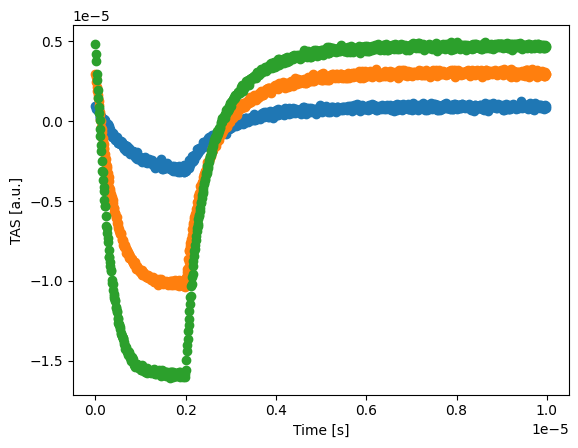

In [3]:
# Define the necessary input parameters for the model
metric = 'mse'
loss = 'linear'
threshold = 10
exp_format = 'TAS'
P = 0.0039 # W
wavelegnth = 850e-9 # m
fpu = 1e5 # Hz
Area = 0.3*0.3*1e-4 # effective pump area in m^-2
penetration_depth = 1e-5*1e-2 # penetration depth in m
pulse_width = 0.2*(1/fpu) # width of the pump pulse in seconds
t0 = 0 # time offset of the pump pulse in seconds
background = 0 # background pump density in m^-3
# Calculate the average absorbed density in photons m^-3
flux, density = get_flux_density(P, wavelegnth, fpu, Area, penetration_depth)
pump_args = {'fpu': fpu , 'pulse_width': pulse_width, 't0': t0, 'P': density, 'background': background, }
fixed_model_args = {'L':100e-9}

t = np.linspace(0,1/fpu,1000)
t = t[:-1]

Gfracs = [0.1,0.5,1]
# concatenate the time and Gfracs
X = None
for Gfrac in Gfracs:
    if X is None:
        X = np.array([t,Gfrac*np.ones(len(t))]).T
    else:
        X = np.concatenate((X,np.array([t,Gfrac*np.ones(len(t))]).T),axis=0) 

y_ = X # dummy data

RateEq_fake = RateEqAgent(params, [X], [y_], model = BT_model, pump_model = square_pump, pump_args = pump_args, fixed_model_args = fixed_model_args, metric = metric, loss = loss, threshold=threshold,minimize=True,exp_format=exp_format)

y = RateEq_fake.run(dum_dic,exp_format=exp_format)
noise = 1e-7
rng = default_rng()
y += rng.standard_normal(len(X))*noise

plt.figure()
for idx, Gfrac in enumerate(Gfracs):
    plt.plot(X[X[:,1]==Gfrac,0], y[X[:,1]==Gfrac],'o',label=str(Gfrac),)

plt.xlabel('Time [s]')
plt.ylabel(exp_format + ' [a.u.]')
plt.show()


## Run the optimization

In [4]:
# Define the Agent and the target metric/loss function
metric = 'mse' # can be 'nrmse', 'mse', 'mae'
loss = 'linear' # can be 'linear', 'huber', 'soft_l1'

RateEq = RateEqAgent(params, [X], [y], model = BT_model, pump_model = square_pump, pump_args = pump_args, fixed_model_args = fixed_model_args, metric = metric, loss = loss, threshold=threshold,minimize=True,exp_format=exp_format)

## MCMC Bayesian Inference for Parameter Fitting
We'll use the `emcee` package to perform Markov Chain Monte Carlo sampling to find the posterior distribution of our model parameters.

In [ ]:
from optimpv.optimizers.BayesInfEmcee.EmceeOptimizer import EmceeOptimizer

# Define the Bayesian Inference object
optimizer = EmceeOptimizer(params = params, agents = RateEq, nwalkers=20, nsteps=1000, burn_in=100, progress=True, name='emcee_opti')

In [6]:
optimizer.optimize()

[INFO 12-05 11:52:01] optimpv.EmceeOptimizer: Running MCMC with 20 walkers for 1000 steps...


----------------------------------------------------



100%|██████████| 1000/1000 [03:40<00:00,  4.53it/s]
[INFO 12-05 11:56:13] optimpv.EmceeOptimizer: MCMC run complete.
[INFO 12-05 11:56:13] optimpv.EmceeOptimizer: MCMC Results (Median & 16th/84th Percentiles)
[INFO 12-05 11:56:13] optimpv.EmceeOptimizer: $k_{\text{direct}}$ (k_direct): 1.014e-17 (+4.11e-17 / -8.05e-18)
[INFO 12-05 11:56:13] optimpv.EmceeOptimizer: $k_{\text{trap}}$ (k_trap): 1.093e+06 (+3.73e+06 / -8.8e+05)
[INFO 12-05 11:56:13] optimpv.EmceeOptimizer: $\sigma$ (cross_section): 3.303e-21 (+3.69e-21 / -1.9e-21)


----------------------------------------------------



{'k_direct': {'median': np.float64(1.0141685849493086e-17),
  '16th': np.float64(2.0958655490036986e-18),
  '84th': np.float64(5.128771568509406e-17),
  'lower_err': np.float64(8.045820300489386e-18),
  'upper_err': np.float64(4.114602983560097e-17)},
 'k_trap': {'median': np.float64(1093471.6934164567),
  '16th': np.float64(213834.34957163996),
  '84th': np.float64(4819191.5241226945),
  'lower_err': np.float64(879637.3438448168),
  'upper_err': np.float64(3725719.830706238)},
 'cross_section': {'median': np.float64(3.3027152605419354e-21),
  '16th': np.float64(1.3977690931666381e-21),
  '84th': np.float64(6.99170978264774e-21),
  'lower_err': np.float64(1.904946167375297e-21),
  'upper_err': np.float64(3.688994522105805e-21)}}

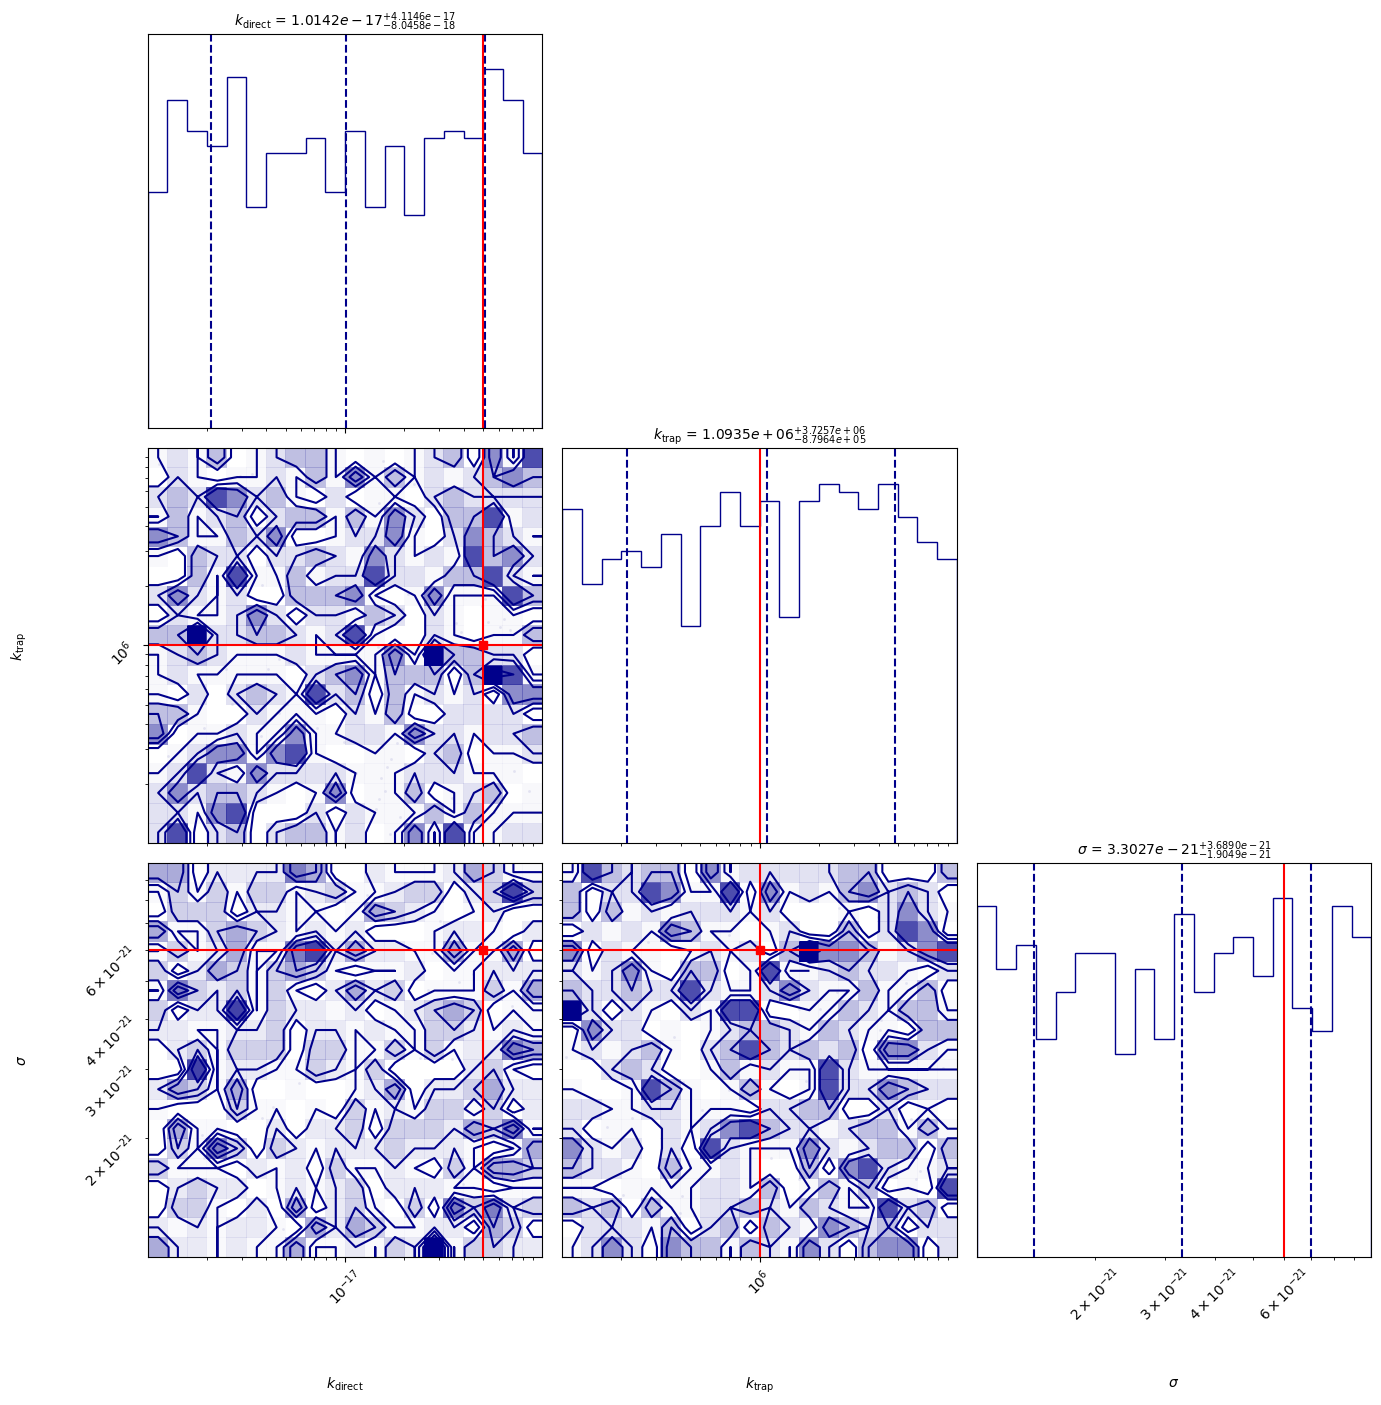

In [7]:
# corner plot
True_params = {p.name: p.value for p in params_orig} # Dictionary to hold true values for parameters
fig = optimizer.plot_corner(True_params=True_params) # Dictionary to hold true values for parameters

fig.set_size_inches(15, 15)

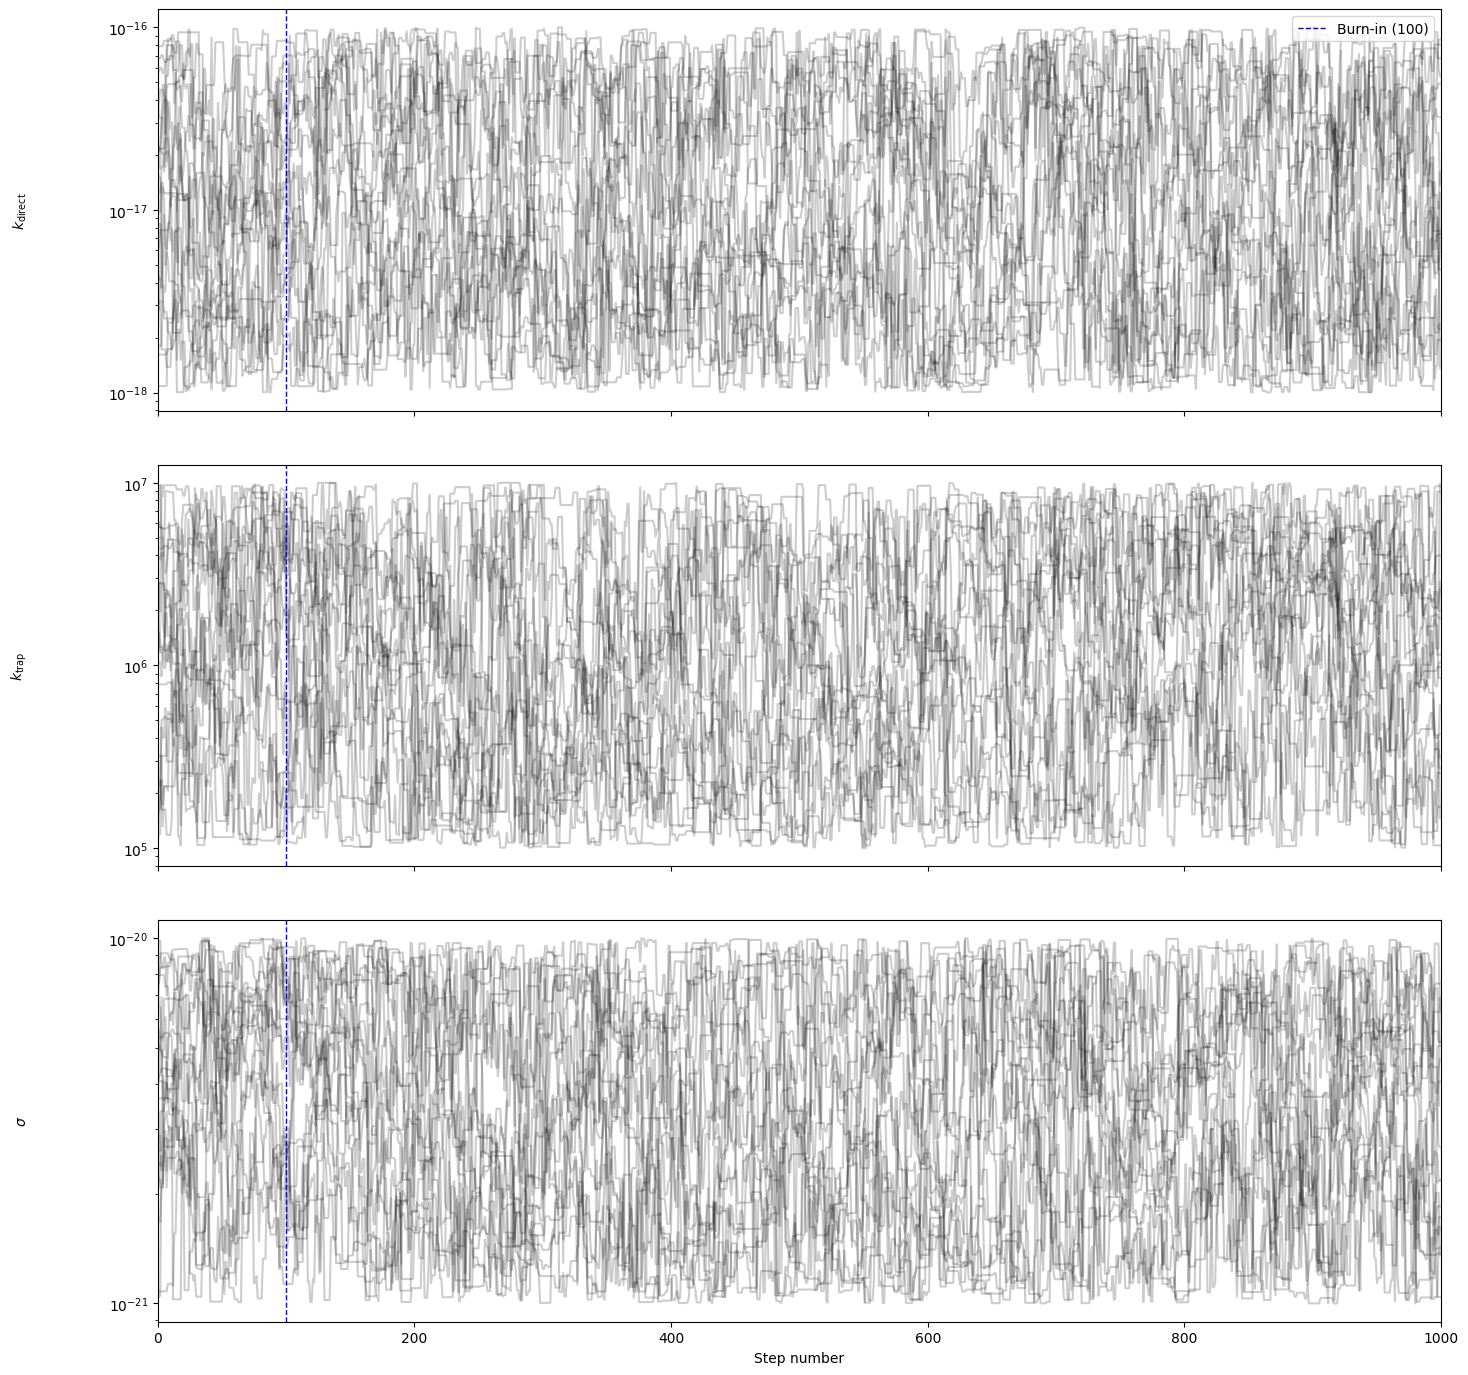

In [8]:
# optimizer.plot_trace()
fig = optimizer.plot_traces()
fig.set_size_inches(15, 15)

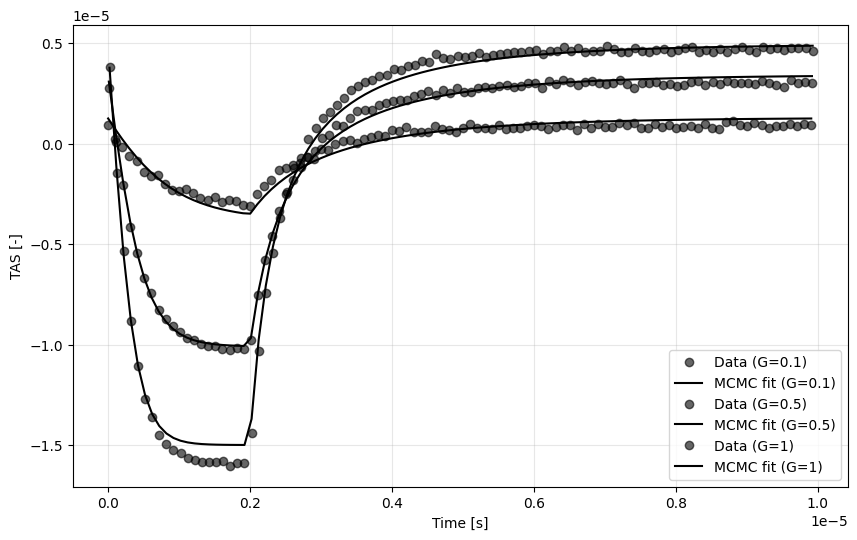

In [9]:
# Run simulation with best-fit parameters
best_fit_params = copy.deepcopy(optimizer.params)

# Create agent with best-fit parameters
best_agent = copy.deepcopy(RateEq)

best_fit_y = best_agent.run(parameters={},exp_format=exp_format)

# Plot the best-fit curves against data
plt.figure(figsize=(10, 6))
for Gfrac in Gfracs:
    
    # keep only every 10th point
    mask = np.zeros(len(X), dtype=bool)
    mask[::10] = True
    mask = np.logical_and(mask, X[:,1] == Gfrac)
    # mask = X[:,1] == Gfrac

    plt.plot(X[mask,0], y[mask], 'ko', alpha=0.6, label=f'Data (G={Gfrac})')
    plt.plot(X[mask,0], best_fit_y[mask], 'k-', label=f'MCMC fit (G={Gfrac})')

plt.xlabel('Time [s]')
plt.ylabel('TAS [-]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()